In [30]:
from google.colab import files
uploaded=files.upload()

Saving data.csv to data.csv


In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report,accuracy_score
from xgboost import XGBClassifier

In [32]:
df = pd.read_csv("data.csv")
print(df.shape)
print(df.info())



(7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null

In [33]:
print(df["TotalCharges"].apply(lambda x: x.strip()).eq("").sum())

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print(df["TotalCharges"].isnull().sum())

11
11


In [35]:
print(pd.crosstab(df["Contract"], df["Churn"], normalize="index") * 100)
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())
print(df.isnull().sum().sum())
df = df.drop("customerID", axis=1)

Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858
0


In [36]:
df["gender"] = df["gender"].map({"Female": 0, "Male": 1})
for col in ["Partner", "Dependents", "PhoneService", "PaperlessBilling", "Churn"]:
    df[col] = df[col].map({"No": 0, "Yes": 1})

contract_map = {"Month-to-month": 0, "One year": 1, "Two year": 2}
df["Contract"] = df["Contract"].map(contract_map)

nominal_cols = ["MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup",
                "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies", "PaymentMethod"]
df = pd.get_dummies(df, columns=nominal_cols, drop_first=True)

print(df.shape)
print(df.select_dtypes(include=["object"]).columns.tolist())


(7043, 30)
[]


In [37]:
bool_cols = df.select_dtypes(include="bool").columns
df[bool_cols] = df[bool_cols].astype(int)
print(df.dtypes.value_counts())

int64      28
float64     2
Name: count, dtype: int64


In [38]:
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True)*100)

Churn
0    5174
1    1869
Name: count, dtype: int64
Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64


In [39]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

model = XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.1,
                        scale_pos_weight=scale_pos_weight, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

print("Train Accuracy:", model.score(X_train, y_train))
print("Test Accuracy:", model.score(X_test, y_test))
print(classification_report(y_test, y_pred))
print("AUC Score:", roc_auc_score(y_test, y_pred_proba))


Train Accuracy: 0.7912673056443025
Test Accuracy: 0.7551454932576295
              precision    recall  f1-score   support

           0       0.91      0.74      0.82      1035
           1       0.53      0.79      0.63       374

    accuracy                           0.76      1409
   macro avg       0.72      0.77      0.72      1409
weighted avg       0.81      0.76      0.77      1409

AUC Score: 0.839849905706683


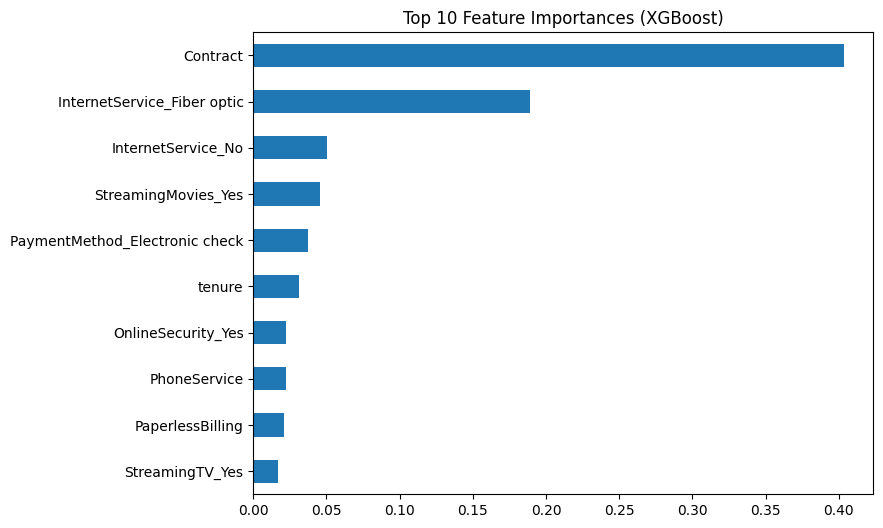

Contract                          0.403364
InternetService_Fiber optic       0.189107
InternetService_No                0.050189
StreamingMovies_Yes               0.045947
PaymentMethod_Electronic check    0.037682
tenure                            0.031131
OnlineSecurity_Yes                0.022631
PhoneService                      0.022290
PaperlessBilling                  0.021279
StreamingTV_Yes                   0.016739
dtype: float32


In [40]:
importances = pd.Series(model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(8,6))
importances.head(10).plot(kind="barh")
plt.title("Top 10 Feature Importances (XGBoost)")
plt.gca().invert_yaxis()
plt.show()

print(importances.head(10))

In [41]:
def predict_churn(gender, senior_citizen, partner, dependents, tenure,
                    phone_service, multiple_lines, internet_service,
                    online_security, online_backup, device_protection,
                    tech_support, streaming_tv, streaming_movies,
                    contract, paperless_billing, payment_method,
                    monthly_charges, total_charges, threshold=0.5):

    data = {
        "gender": 1 if gender == "Male" else 0,
        "SeniorCitizen": senior_citizen,
        "Partner": 1 if partner == "Yes" else 0,
        "Dependents": 1 if dependents == "Yes" else 0,
        "tenure": tenure,
        "PhoneService": 1 if phone_service == "Yes" else 0,
        "Contract": {"Month-to-month": 0, "One year": 1, "Two year": 2}[contract],
        "PaperlessBilling": 1 if paperless_billing == "Yes" else 0,
        "MonthlyCharges": monthly_charges,
        "TotalCharges": total_charges,
    }

    one_hot_template = {col: 0 for col in X_train.columns if col not in data}
    data.update(one_hot_template)

    if f"MultipleLines_{multiple_lines}" in data:
        data[f"MultipleLines_{multiple_lines}"] = 1
    if f"InternetService_{internet_service}" in data:
        data[f"InternetService_{internet_service}"] = 1
    if f"OnlineSecurity_{online_security}" in data:
        data[f"OnlineSecurity_{online_security}"] = 1
    if f"OnlineBackup_{online_backup}" in data:
        data[f"OnlineBackup_{online_backup}"] = 1
    if f"DeviceProtection_{device_protection}" in data:
        data[f"DeviceProtection_{device_protection}"] = 1
    if f"TechSupport_{tech_support}" in data:
        data[f"TechSupport_{tech_support}"] = 1
    if f"StreamingTV_{streaming_tv}" in data:
        data[f"StreamingTV_{streaming_tv}"] = 1
    if f"StreamingMovies_{streaming_movies}" in data:
        data[f"StreamingMovies_{streaming_movies}"] = 1
    if f"PaymentMethod_{payment_method}" in data:
        data[f"PaymentMethod_{payment_method}"] = 1

    input_df = pd.DataFrame([data])
    input_df = input_df[X_train.columns]

    probability = model.predict_proba(input_df)[:, 1][0]
    prediction = "Will Churn" if probability >= threshold else "Will Stay"

    return f"Churn Probability: {probability:.2%} | Prediction: {prediction}"

In [42]:
result = predict_churn(
    gender="Male", senior_citizen=0, partner="No", dependents="No",
    tenure=5, phone_service="Yes", multiple_lines="No",
    internet_service="Fiber optic", online_security="No",
    online_backup="No", device_protection="No", tech_support="No",
    streaming_tv="Yes", streaming_movies="Yes",
    contract="Month-to-month", paperless_billing="Yes",
    payment_method="Electronic check", monthly_charges=85.0, total_charges=425.0
)
print(result)

Churn Probability: 86.71% | Prediction: Will Churn
